# Inicialización 

La cadena de gimnasios Model Fitness está desarrollando una estrategia de interacción con clientes basada en datos analíticos.

Uno de los problemas más comunes que enfrentan los gimnasios y otros servicios es la pérdida de clientes. ¿Cómo descubres si un/a cliente ya no está contigo? Puedes calcular la pérdida en función de las personas que se deshacen de sus cuentas o no renuevan sus contratos. Sin embargo, a veces no es obvio que un/a cliente se haya ido: puede que se vaya de puntillas.

Los indicadores de pérdida varían de un campo a otro. Si un usuario o una usuaria compra en una tienda en línea con poca frecuencia, pero con regularidad, no se puede decir que ha huido. Pero si durante dos semanas no ha abierto un canal que se actualiza a diario, es motivo de preocupación: es posible que tu seguidor o seguidor/a se haya aburrido y te haya abandonado.

En el caso de un gimnasio, tiene sentido decir que un/a cliente se ha ido si no viene durante un mes. Por supuesto, es posible que estén en Cancún y retomen sus visitas cuando regresen, pero ese no es un caso típico. Por lo general, si un/a cliente se une, viene varias veces y luego desaparece, es poco probable que regrese.

Con el fin de combatir la cancelación, Model Fitness ha digitalizado varios de sus perfiles de clientes. Tu tarea consiste en analizarlos y elaborar una estrategia de retención de clientes.

## Llevar a cabo el análisis exploratorio de datos (EDA)

Observa el dataset: ¿contiene alguna característica ausente? Estudia los valores promedio y la desviación estándar (utiliza el método describe()).

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, precision_score, recall_score
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans
df = pd.read_csv('gym_churn_us.csv')
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


¿El dataset contiene valores ausentes?

In [12]:
df.isna().sum() 

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

El dataset no contiene valores ausentes.

### Observa los valores medios de las características en dos grupos: para las personas que se fueron (cancelación) y para las que se quedaron (utiliza el método groupby()).

In [13]:
churn_means = df.groupby('Churn').mean(numeric_only=True)
churn_means

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


El análisis de los valores promedio por grupo revela diferencias significativas entre los clientes que cancelaron su membresía y aquellos que permanecieron activos.

Los clientes que cancelaron presentan contratos considerablemente más cortos, menos meses restantes hasta el fin de su contrato y un tiempo de permanencia mucho menor en el gimnasio. Asimismo, muestran una frecuencia de visitas más baja, especialmente durante el último mes, lo cual sugiere una pérdida gradual de interés previa a la cancelación.

Además, los clientes que permanecieron activos tienden a participar más en clases grupales, gastar más en servicios adicionales

### Traza histogramas de barras y distribuciones de características para aquellas personas que se fueron (cancelación) y para las que se quedaron.

/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


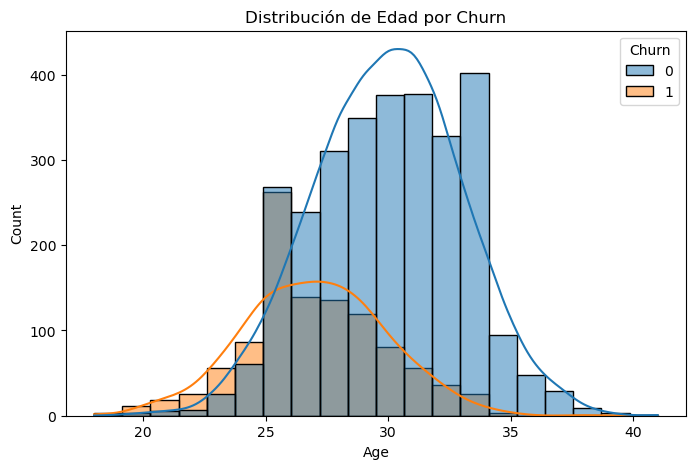

In [14]:
# Vamos a comparar Churn = 0 (se quedaron) vs Churn = 1 (cancelaron).
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Churn', bins=20, kde=True)
plt.title('Distribución de Edad por Churn')
plt.show()

El histograma de la edad muestra que los clientes que cancelaron su membresía tienden a ser ligeramente más jóvenes que aquellos que permanecieron activos. La mayor concentración de cancelaciones se observa entre los 24 y 29 años, mientras que los clientes que se quedaron presentan una distribución centrada alrededor de los 30 años.

### Crea una matriz de correlación y muéstrala.

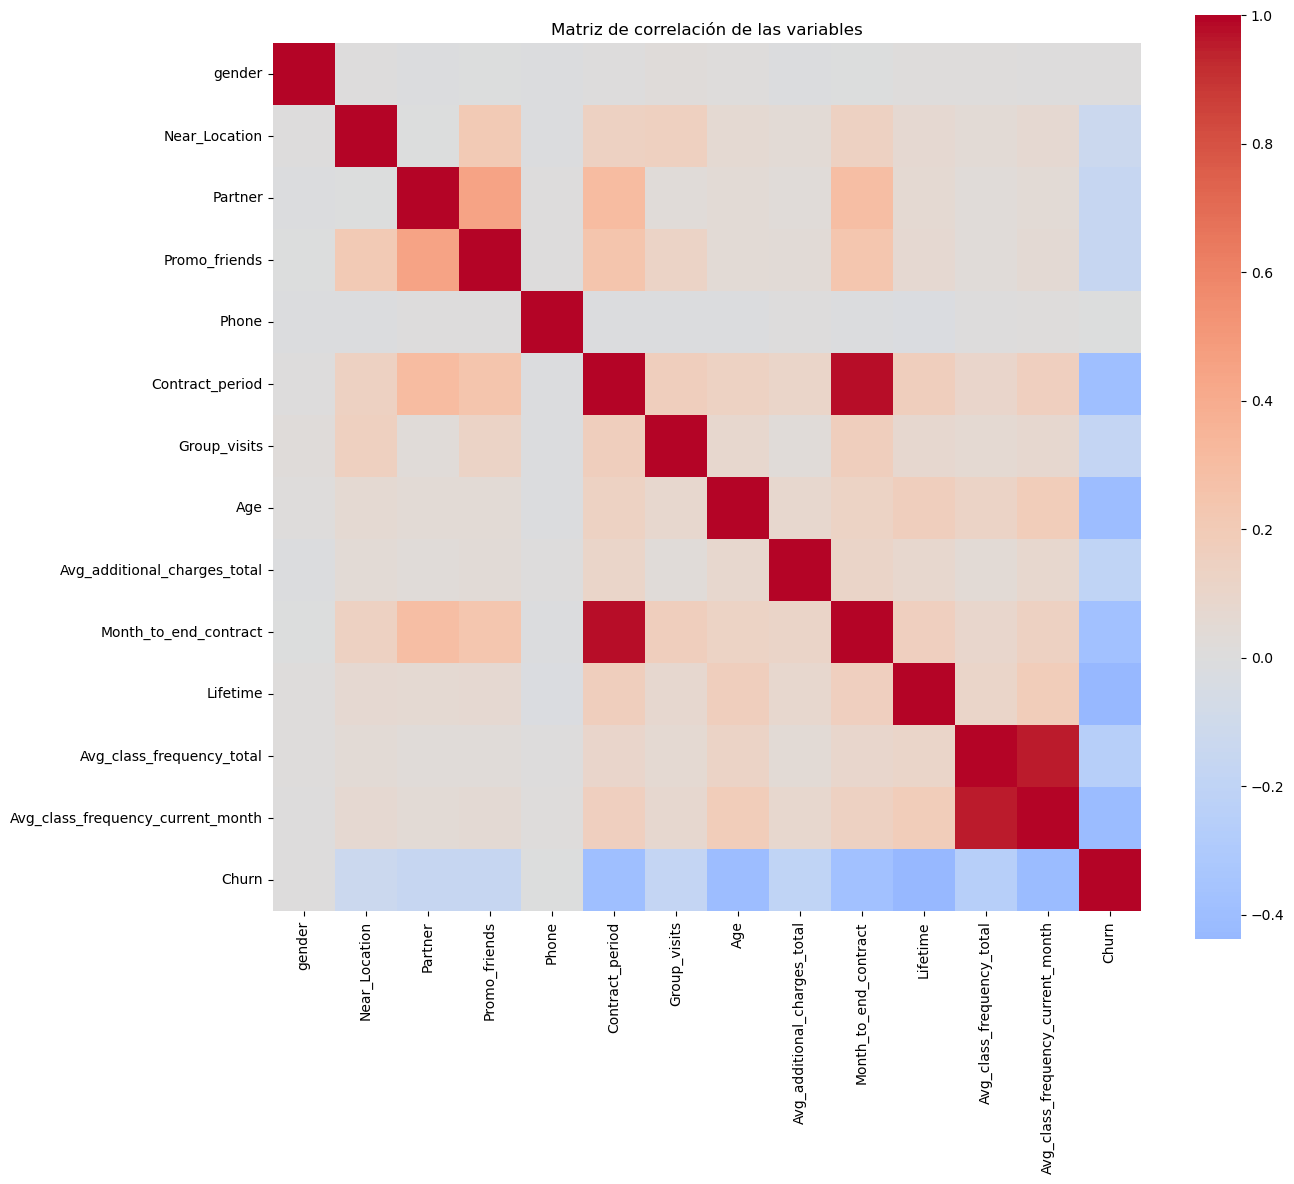

In [15]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    square=True
)
plt.title('Matriz de correlación de las variables')
plt.show()

¿Qué muestra esta matriz de correlación?

Rojo intenso → correlación positiva fuerte

Azul intenso → correlación negativa fuerte

Colores claros/gris → poca o ninguna correlación

La matriz de correlación muestra relaciones claras entre las variables relacionadas con el comportamiento del cliente. Se observa una fuerte correlación positiva entre la frecuencia promedio total de visitas y la frecuencia del mes actual, así como entre la duración del contrato y los meses restantes hasta su finalización.

En relación con la variable objetivo (Churn), se identifican correlaciones negativas moderadas con la frecuencia de visitas, el tiempo como cliente y la duración del contrato. Esto indica que clientes más activos, con contratos más largos y mayor antigüedad, presentan una menor probabilidad de cancelación.

Por otro lado, variables como el género, la edad y la disponibilidad de número telefónico presentan correlaciones bajas con la cancelación, lo que sugiere que su impacto individual es limitado.

## Paso 3. Construir un modelo para predecir la cancelación de usuarios

### Crea un modelo de clasificación binaria para clientes donde la característica objetivo es la marcha del usuario o la usuaria el mes siguiente.

Divide los datos en conjuntos de entrenamiento y validación utilizando la función train_test_split().

In [16]:
# Separar características (X) y objetivo (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Dividir en entrenamiento y validación (train_test_split)
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Distribución en y:")
print(y.value_counts(normalize=True))

print("\nDistribución en y_train:")
print(y_train.value_counts(normalize=True))

print("\nDistribución en y_val:")
print(y_val.value_counts(normalize=True))

Distribución en y:
Churn
0    0.73475
1    0.26525
Name: proportion, dtype: float64

Distribución en y_train:
Churn
0    0.734688
1    0.265313
Name: proportion, dtype: float64

Distribución en y_val:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


Las proporciones son prácticamente idénticas.

Tras dividir los datos en conjuntos de entrenamiento y validación, se verificó que la proporción de clientes que cancelaron y los que permanecieron activos se mantuviera prácticamente idéntica en ambos conjuntos. Esto confirma que la estratificación se realizó correctamente, evitando sesgos en el entrenamiento y evaluación del modelo.

### - Entrena el modelo en el set de entrenamiento con dos métodos:
    - regresión logística;
    - bosque aleatorio.

In [17]:
# Estandarizar los datos con StandardScaler
scaler = StandardScaler()

X_train_st = scaler.fit_transform(X_train)
X_val_st = scaler.transform(X_val)

# Modelo 1: Regresión Logística
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_st, y_train)

# Modelo 2: Bosque Aleatorio (Random Forest)
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

Para predecir la cancelación de clientes, se entrenaron dos modelos de clasificación binaria utilizando el conjunto de entrenamiento.

En primer lugar, se entrenó un modelo de regresión logística, para lo cual se estandarizaron previamente las características numéricas. Este modelo permite interpretar fácilmente la influencia de cada variable sobre la probabilidad de cancelación.

En segundo lugar, se entrenó un modelo de bosque aleatorio, el cual no requiere estandarización de los datos y es capaz de capturar relaciones no lineales entre las características. Ambos modelos fueron entrenados utilizando los mismos datos de entrenamiento para permitir una comparación justa de su desempeño.

### - Evalúa la exactitud, precisión y *recall* para ambos modelos utilizando los datos de validación. Utilízalos para comparar los modelos. ¿Qué modelo dio mejores resultados?

Recuerda indicar el parámetro `random_state` cuando dividas los datos y definas el algoritmo.

In [18]:
# Obtener predicciones en el set de validación
#  Regresión logística
lr_pred = lr_model.predict(X_val_st)

lr_accuracy = accuracy_score(y_val, lr_pred)
lr_precision = precision_score(y_val, lr_pred)
lr_recall = recall_score(y_val, lr_pred)

# Bosque aleatorio
rf_pred = rf_model.predict(X_val)

rf_accuracy = accuracy_score(y_val, rf_pred)
rf_precision = precision_score(y_val, rf_pred)
rf_recall = recall_score(y_val, rf_pred)

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_accuracy, rf_accuracy],
    'Precision': [lr_precision, rf_precision],
    'Recall': [lr_recall, rf_recall]
})

results

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.92500,0.880000,0.830189
1,Random Forest,0.92625,0.884422,0.830189


Se evaluaron los modelos de regresión logística y bosque aleatorio utilizando los datos de validación. Ambos modelos mostraron un desempeño sólido, con valores de exactitud superiores al 92%.

El modelo de bosque aleatorio presentó una exactitud y precisión ligeramente superiores a las de la regresión logística, mientras que ambos modelos alcanzaron el mismo valor de recall. Dado que el recall es una métrica clave en el problema de cancelación y el bosque aleatorio mostró un mejor desempeño general, este modelo fue considerado como el más adecuado para la predicción de la cancelación de clientes.

## Paso 4. Crear clústeres de usuarios/as
Deja de lado la columna con datos sobre la cancelación e identifica los clústeres de objetos (usuarios/as)
Estandariza los datos.

In [19]:
# Dejar fuera la columna de cancelación (Churn)
X_cluster = df.drop('Churn', axis=1)

# Estandarizar los datos para clustering
scaler = StandardScaler()
X_cluster_st = scaler.fit_transform(X_cluster)
pd.DataFrame(X_cluster_st, columns=X_cluster.columns).describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
count,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03
mean,7.771561e-17,1.847411e-16,-4.440892e-17,-6.927792e-17,1.092459e-16,-5.373479e-17,-8.171241e-17,4.014566e-16,2.424727e-16,-8.881784e-18,2.842171e-17,-1.598721e-17,6.927792e-17
std,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00
min,-1.020715e+00,-2.337100e+00,-9.738420e-01,-6.679308e-01,-3.059852e+00,-8.092194e-01,-8.374985e-01,-3.432900e+00,-1.523667e+00,-7.928727e-01,-9.935851e-01,-1.932903e+00,-1.678472e+00
25%,-1.020715e+00,4.278807e-01,-9.738420e-01,-6.679308e-01,3.268132e-01,-8.092194e-01,-8.374985e-01,-6.704349e-01,-8.103801e-01,-7.928727e-01,-7.268329e-01,-7.181647e-01,-7.637430e-01
50%,9.797059e-01,4.278807e-01,-9.738420e-01,-6.679308e-01,3.268132e-01,-8.092194e-01,-8.374985e-01,-5.655380e-02,-1.113055e-01,-7.928727e-01,-1.933286e-01,-4.757761e-02,-4.509753e-02
75%,9.797059e-01,4.278807e-01,1.026861e+00,1.497161e+00,3.268132e-01,2.898901e-01,1.194032e+00,5.573273e-01,6.643506e-01,4.002244e-01,3.401757e-01,6.759005e-01,7.060246e-01
max,9.797059e-01,4.278807e-01,1.026861e+00,1.497161e+00,3.268132e-01,1.608822e+00,1.194032e+00,3.626733e+00,4.210422e+00,1.831941e+00,7.275732e+00,4.263501e+00,4.160181e+00


Tras excluir la variable de cancelación, las características fueron estandarizadas utilizando StandardScaler. El análisis de los estadísticos descriptivos muestra que todas las variables presentan una media cercana a cero y una desviación estándar cercana a uno, lo que confirma que la estandarización se realizó correctamente.

Este paso es fundamental para la creación de clústeres, ya que garantiza que todas las variables contribuyan de manera equitativa al cálculo de distancias durante el proceso de agrupamiento.

### Utiliza la función linkage() para crear una matriz de distancias basada en la matriz de características estandarizada y trazar un dendrograma. Nota: ¡renderizar el dendrograma puede llevar tiempo! Utiliza el gráfico resultante para estimar el número de clústeres que puedes destacar.

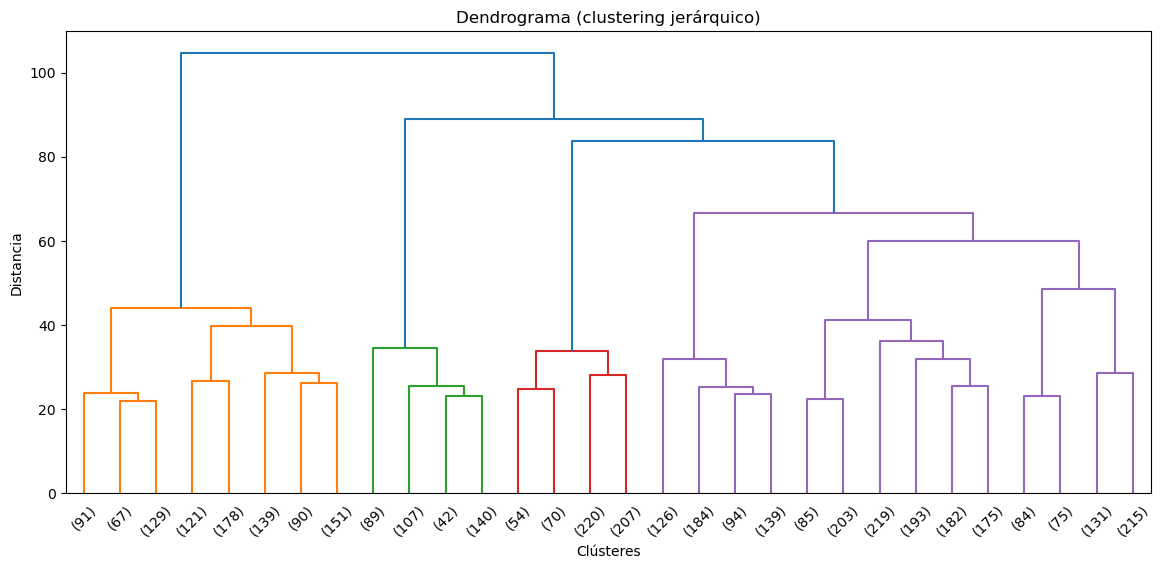

In [20]:
# Crear la matriz de distancias con linkage()
linked = linkage(X_cluster_st, method='ward')

plt.figure(figsize=(14, 6))

dendrogram(
    linked,
    truncate_mode='lastp',  # muestra solo los últimos merges
    p=30,                   # número de grupos a mostrar
    leaf_rotation=45,
    leaf_font_size=10
)

plt.title('Dendrograma (clustering jerárquico)')
plt.xlabel('Clústeres')
plt.ylabel('Distancia')
plt.show()

A partir del dendrograma obtenido mediante clustering jerárquico, se identifican incrementos significativos en la distancia de enlace al reducir el número de clústeres por debajo de cuatro o cinco. Esto indica que unir más grupos a partir de ese punto implica combinar usuarios con comportamientos significativamente distintos.

Por lo tanto, se concluye que una segmentación en 4–5 clústeres es adecuada para describir los diferentes perfiles de usuarios. En el análisis posterior se utilizaron 5 clústeres para obtener una segmentación más detallada.

### Entrena el modelo de clustering con el algortimo K-means y predice los clústeres de clientes. (Deja que el número de clústeres sea n=5 para que sea más sencillo comparar los resultados con los del resto del estudiantado. Sin embargo, en la vida real, nadie te dará tales pistas, así que tendrás que decidir basándote en el gráfico del paso anterior.)

In [21]:
# Entrenar el modelo K-Means (n = 5)
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)
clusters = kmeans.fit_predict(X_cluster_st)

# Agregar los clústeres al DataFrame original
df['cluster'] = clusters

# Ver tamaño de cada clúster
df['cluster'].value_counts().sort_index()

#  Verifica rápidamente las medias por clúster
cluster_means = df.groupby('cluster').mean(numeric_only=True)
cluster_means

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
cluster,,,,,,,,,,,,,,
0,0.502370,0.949447,0.829384,0.998420,1.0,3.097946,0.448657,29.104265,141.774331,2.887836,3.772512,1.770536,1.669581,0.246445
1,0.554556,0.849269,0.263217,0.052868,1.0,2.606299,0.436445,30.008999,159.774265,2.419573,4.780652,2.745505,2.733173,0.089989
2,0.499422,0.937572,0.737572,0.478613,1.0,11.854335,0.546821,29.905202,163.509804,10.812717,4.677457,2.006405,1.998179,0.021965
3,0.485738,0.718011,0.299919,0.018745,1.0,1.914425,0.276284,28.083945,129.496414,1.821516,2.195599,1.225192,0.967967,0.572942
4,0.523316,0.862694,0.471503,0.305699,0.0,4.777202,0.427461,29.297927,144.208179,4.466321,3.940415,1.854211,1.723967,0.266839


El análisis de clustering permitió identificar cinco segmentos distintos de clientes con comportamientos claramente diferenciados. El clúster con mayor tasa de cancelación está compuesto principalmente por clientes nuevos con contratos cortos, baja frecuencia de visitas y poco tiempo restante de contrato, lo que indica un alto riesgo de churn temprano.

En contraste, los clústeres con menor tasa de cancelación se caracterizan por contratos largos, mayor tiempo como cliente, alta participación en clases grupales y mayor gasto en servicios adicionales, lo que refleja un alto nivel de compromiso con el gimnasio.

Estos resultados sugieren que las estrategias de retención deben enfocarse especialmente en los clientes nuevos y con baja actividad, mientras que los clientes más comprometidos pueden ser utilizados como embajadores de la marca y beneficiarse de programas de fidelización.

### Mira los valores medios de característica para los clústeres.¿Hay algo que te llame la atención?

El contrato es el factor más diferenciador.

La duración del contrato y los meses restantes son los factores más determinantes en la cancelación.

El clúster 3 es un outlier negativo. Es un perfil clásico de abandono temprano.

Los clientes más fieles no necesitan promociones

Los clústeres se diferencian principalmente por nivel de compromiso, no por características demográficas.


### Traza distribuciones de características para los clústeres. ¿Notas algo?

/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


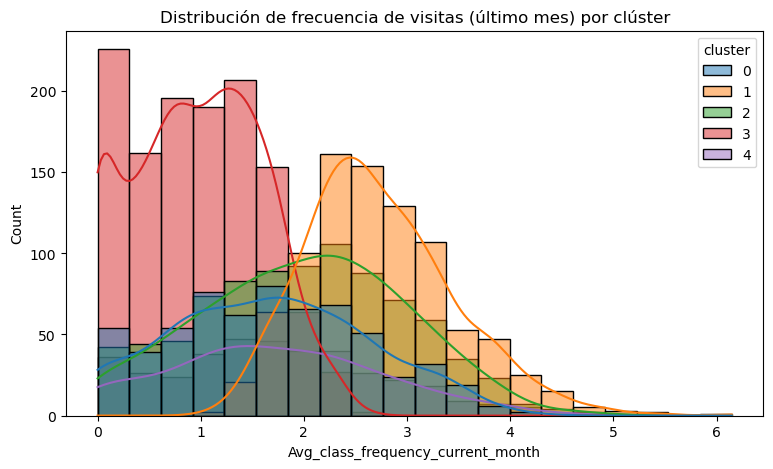

In [22]:
# Traza distribuciones de características por clúster
# Frecuencia de visitas del último mes 
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df,
    x='Avg_class_frequency_current_month',
    hue='cluster',
    bins=20,
    kde=True,
    palette='tab10'
)
plt.title('Distribución de frecuencia de visitas (último mes) por clúster')
plt.show()

/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


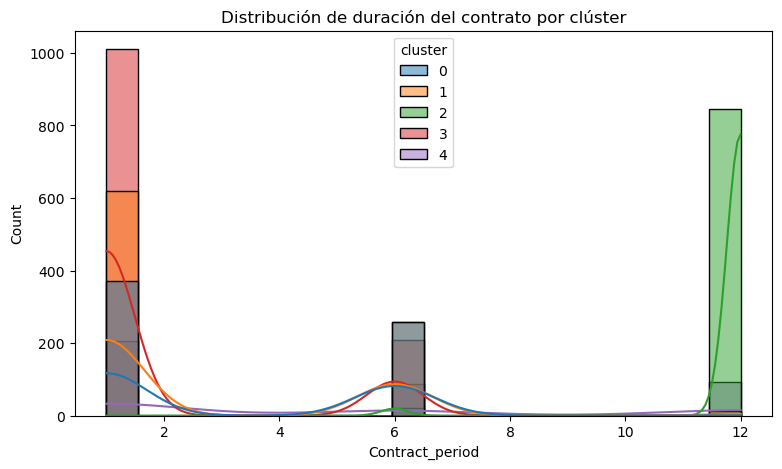

In [23]:
#  Duración del contrato
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df,
    x='Contract_period',
    hue='cluster',
    bins=20,
    kde=True,
    palette='tab10'
)
plt.title('Distribución de duración del contrato por clúster')
plt.show()

/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


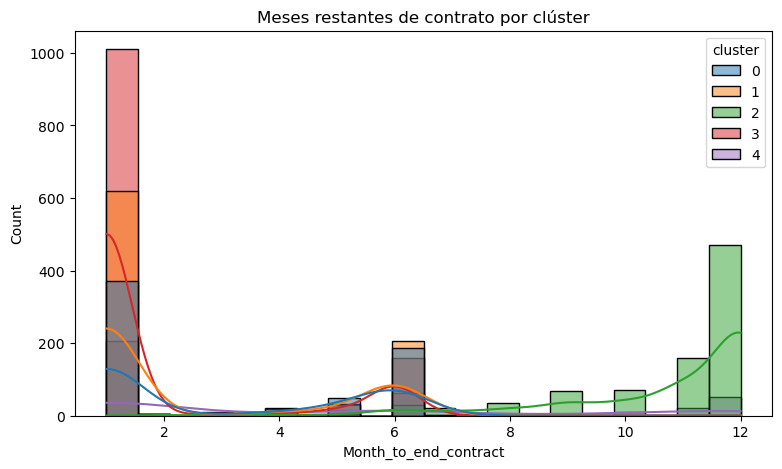

In [24]:
#  Meses restantes de contrato
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df,
    x='Month_to_end_contract',
    hue='cluster',
    bins=20,
    kde=True,
    palette='tab10'
)
plt.title('Meses restantes de contrato por clúster')
plt.show()

/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


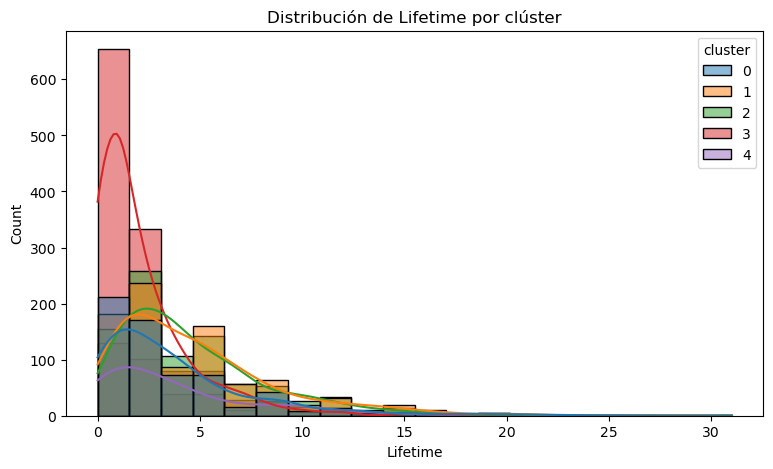

In [25]:
# Lifetime (antigüedad)
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df,
    x='Lifetime',
    hue='cluster',
    bins=20,
    kde=True,
    palette='tab10'
)
plt.title('Distribución de Lifetime por clúster')
plt.show()

/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


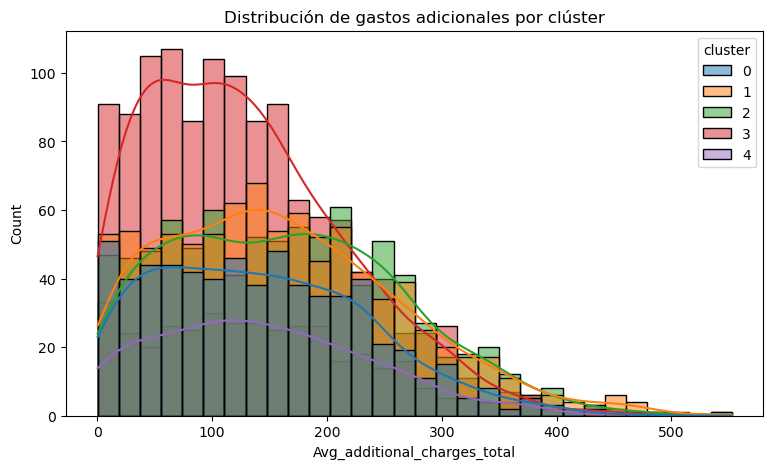

In [26]:
# Gastos adicionales
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df,
    x='Avg_additional_charges_total',
    hue='cluster',
    bins=30,
    kde=True,
    palette='tab10'
)
plt.title('Distribución de gastos adicionales por clúster')
plt.show()

Al analizar las distribuciones de las características por clúster, se observan diferencias claras entre los grupos. Los clústeres con mayor tasa de cancelación se concentran en valores bajos de frecuencia de visitas, duración del contrato y tiempo como cliente, lo que indica un bajo nivel de compromiso.

En contraste, los clústeres con menor tasa de cancelación presentan distribuciones desplazadas hacia mayores valores de actividad y contratos más largos. Las variables demográficas muestran una alta superposición entre clústeres, lo que confirma que el comportamiento del cliente es el principal factor diferenciador.

### Calcula la tasa de cancelación para cada clúster (utiliza el método groupby()). ¿Difieren en términos de tasa de cancelación? ¿Qué grupos son propensos a irse y cuáles son leales?

In [27]:
churn_by_cluster = (
    df
    .groupby('cluster')['Churn']
    .mean()
    .sort_values(ascending=False)
)

churn_by_cluster

cluster
3    0.572942
4    0.266839
0    0.246445
1    0.089989
2    0.021965
Name: Churn, dtype: float64

¿Difieren en términos de tasa de cancelación?

Sí, de manera muy marcada.

La diferencia entre el clúster más riesgoso (3) y el más leal (2) es de más de 55 puntos porcentuales.

Esto confirma que los clústeres capturan patrones reales de comportamiento relacionados con la cancelación.

¿Qué grupos son propensos a irse?

Cluster 3 muy alto riesgo a cancelar

La tasa de cancelación varía significativamente entre los clústeres, lo que indica que existen perfiles claramente diferenciados de clientes. Los clientes con contratos cortos y baja actividad son los más propensos a abandonar el gimnasio, mientras que aquellos con contratos largos y alta frecuencia de visitas presentan una lealtad notable.

### **Paso 5. Saca conclusiones y haz recomendaciones básicas sobre el trabajo con clientes**

Llega a conclusiones y formula recomendaciones con respecto a la estrategia para la interacción y retención de clientes.

No necesitas entrar en detalles. Bastarán tres o cuatro principios esenciales y ejemplos de su implementación en forma de pasos de *marketing* específicos.

1. Priorizar la retención temprana de clientes nuevos

Acciones concretas:
	•	Programa de onboarding durante el primer mes (rutinas guiadas, seguimiento del entrenador).
	•	Mensajes automáticos si la frecuencia de visitas cae en el primer o segundo mes.
	•	Incentivos por completar un número mínimo de visitas en el primer mes.
2. Fomentar contratos de mayor duración

Acciones concretas:
	•	Descuentos o beneficios adicionales al renovar contratos de 6 o 12 meses.
	•	Ofertas de renovación anticipada cuando el contrato esté por expirar.
	•	Comunicación personalizada destacando el ahorro de contratos largos.
3. Aumentar el compromiso a través de la actividad y clases grupales

Acciones concretas:
	•	Promover clases grupales para clientes con baja asistencia.
	•	Retos mensuales o semanales de actividad.
	•	Recordatorios personalizados cuando disminuye la frecuencia del último mes.
4. Fidelizar y aprovechar a los clientes más leales

Acciones concretas:
	•	Programas de lealtad o membresías premium.
	•	Beneficios exclusivos para clientes de larga duración.
	•	Incentivos por referir nuevos clientes.

Con base en estos hallazgos, se recomienda enfocar los esfuerzos de retención en los primeros meses de la relación con el cliente, fomentar contratos de mayor duración y promover una mayor participación en actividades del gimnasio. Asimismo, los clientes más leales pueden ser utilizados como embajadores de la marca mediante programas de fidelización y referidos.